# Machine Learning-Based Air Quality Classification

## 1. Importing Libraries

In [1]:
#for data handling
import pandas as pd
import numpy as np

#for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#for date and time
from datetime import datetime

## 2. Loading the Dataset

In [2]:
df= pd.read_csv("city_day.csv")

## 3. Initial Data Inspection

In [3]:
df.head(4)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN


In [4]:
df.tail(4)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


In [5]:
print("Rows and Columns: ", df.shape)

Rows and Columns:  (29531, 16)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [7]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df.nunique()

City             26
Date           2009
PM2.5         11716
PM10          12571
NO             5776
NO2            7404
NOx            8156
NH3            5922
CO             1779
SO2            4761
O3             7699
Benzene        1873
Toluene        3608
Xylene         1561
AQI             829
AQI_Bucket        6
dtype: int64

## 4. Exploratory Data Analysis

### 4.1 Distribution of Air Qaulity Index

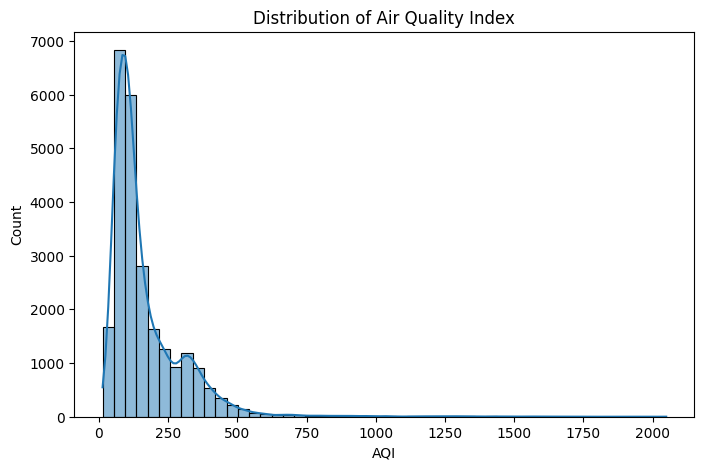

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["AQI"], bins=50, kde=True)
plt.title("Distribution of Air Quality Index")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

### 4.2 Correlation Analysis

In [11]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

In [12]:
corr = df.select_dtypes(include=['float64','int64']).corr()
corr["AQI"].sort_values(ascending=False)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

### 4.3 Correlation Heatmap

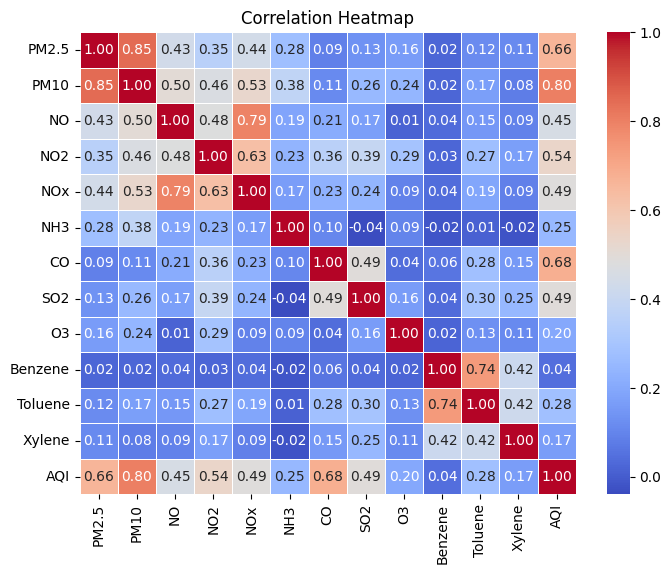

In [13]:
plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['float64','int64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
df[["PM2.5","PM10","AQI"]].corr()

,PM2.5,PM10,AQI
PM2.5,1.000000,0.846498,0.659181
PM10,0.846498,1.000000,0.803313
AQI,0.659181,0.803313,1.000000


### 4.4 City Wise Average AQI

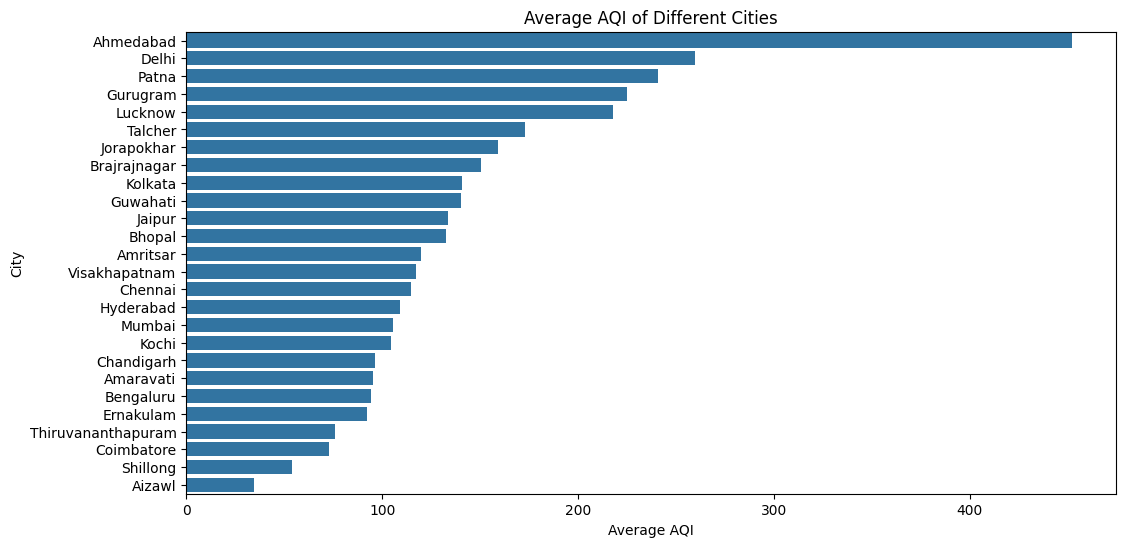

In [15]:
plt.figure(figsize=(12,6))

city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

sns.barplot(
    x=city_aqi.values,
    y=city_aqi.index
)

plt.title("Average AQI of Different Cities")
plt.xlabel("Average AQI")
plt.ylabel("City")

plt.show()

### 4.5 Distribution of Major Pollutants

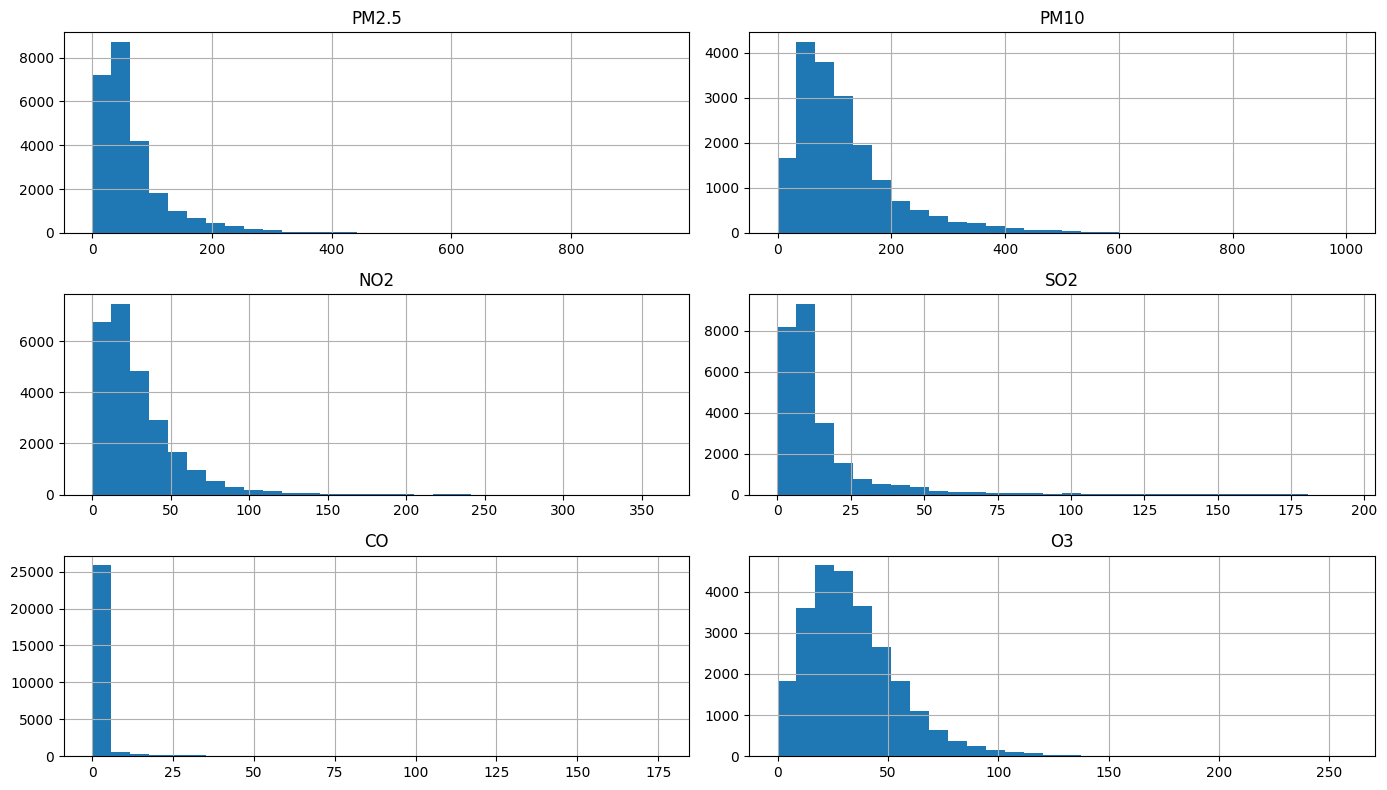

In [16]:
pollutants = ["PM2.5","PM10","NO2","SO2","CO","O3"]

df[pollutants].hist(
    figsize=(14,8),
    bins=30
)

plt.tight_layout()

plt.show()

### 4.6 Outlier detection

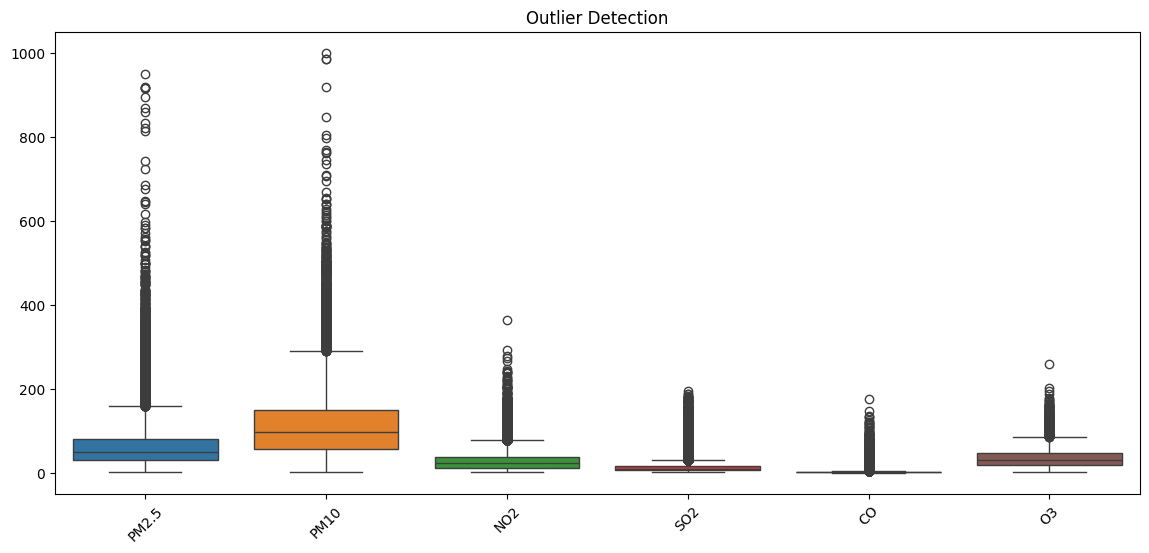

In [17]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df[pollutants])

plt.xticks(rotation=45)

plt.title("Outlier Detection")

plt.show()

### 4.7 AQI Bucket Distribution

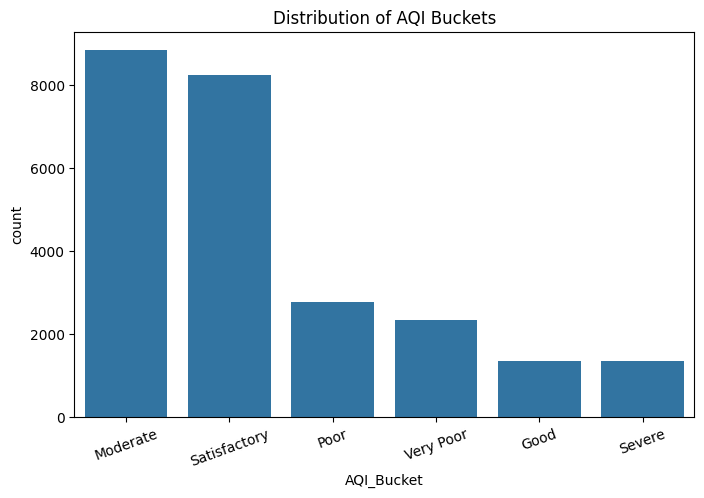

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index
)

plt.title("Distribution of AQI Buckets")
plt.xticks(rotation=20)

plt.show()

### 4.8 Missing Values Analysis

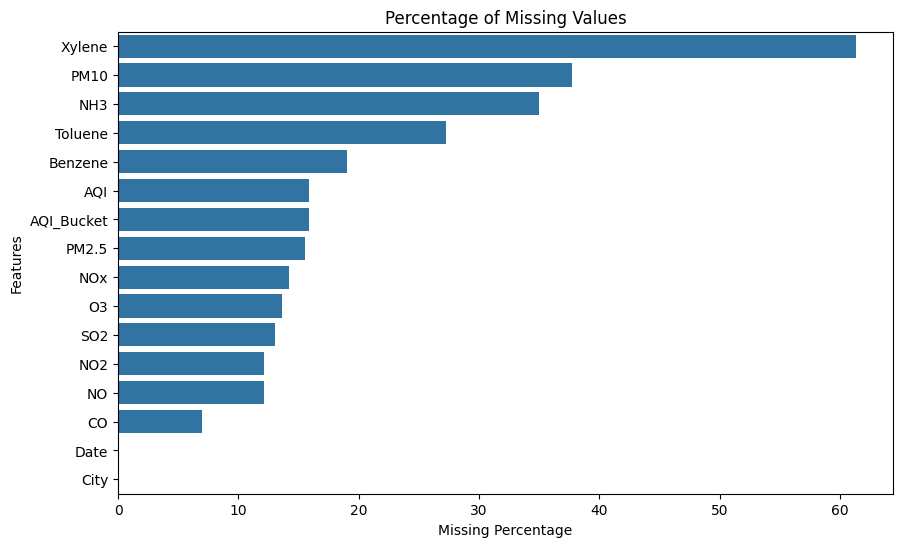

In [19]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Percentage of Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")

plt.show()

## 5. Data PreProcessing

### 5.1 creating a copy of the dataset

In [20]:
df_copy= df.copy()
print(df_copy.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


### 5.2 Checking Missing Values

In [21]:
df_copy.isnull().sum().sort_values(ascending=False)

Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
Date              0
City              0
dtype: int64

In [22]:
df_copy = df_copy.dropna(subset=["AQI"])

### 5.3 Date Time Conversion

In [23]:
df_copy["Date"] = pd.to_datetime(df_copy["Date"])

#### 5.3.1 Extracting date format into seperate columns

In [24]:
df_copy["Year"] = df_copy["Date"].dt.year
df_copy["Month"] = df_copy["Date"].dt.month
df_copy["Day"] = df_copy["Date"].dt.day

In [25]:
df_copy.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
28,Ahmedabad,2015-01-29,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1,29
29,Ahmedabad,2015-01-30,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1,30
30,Ahmedabad,2015-01-31,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1,31
31,Ahmedabad,2015-02-01,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2015,2,1
32,Ahmedabad,2015-02-02,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2015,2,2


#### 5.3.2 Dropping Unnecessary Column

In [26]:
df_copy.drop("Date", axis=1, inplace=True)

In [27]:
df_copy.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
28,Ahmedabad,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1,29
29,Ahmedabad,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1,30
30,Ahmedabad,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1,31
31,Ahmedabad,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,25.87,782.0,Severe,2015,2,1
32,Ahmedabad,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,35.61,914.0,Severe,2015,2,2


### 5.4 Handling Missing Values

#### 5.4.1 Checking Missing Percentage

In [28]:
missing = (df_copy.isnull().sum() / len(df_copy)) * 100

missing = pd.DataFrame({
    "Missing Values": df_copy.isnull().sum(),
    "Percentage": missing
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Xylene,15372,61.859155
PM10,7086,28.515091
NH3,6536,26.301811
Toluene,5826,23.444668
Benzene,3535,14.225352
NOx,1857,7.472837
O3,807,3.247485
PM2.5,678,2.728370
SO2,605,2.434608
CO,445,1.790744


##### *dropping columns where missing percentage>60

In [29]:
df_copy.drop("Xylene", axis=1, inplace=True)

In [30]:
df_copy.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Year,Month,Day
28,Ahmedabad,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,209.0,Poor,2015,1,29
29,Ahmedabad,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,328.0,Very Poor,2015,1,30
30,Ahmedabad,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,514.0,Severe,2015,1,31
31,Ahmedabad,135.99,NaN,43.48,42.08,84.57,NaN,43.48,75.23,102.70,0.40,0.04,782.0,Severe,2015,2,1
32,Ahmedabad,178.33,NaN,54.56,35.31,72.80,NaN,54.56,55.04,107.38,0.46,0.06,914.0,Severe,2015,2,2


#### 5.4.2 Filling Numeric Data

In [31]:
numeric_cols = df_copy.select_dtypes(include=["float64", "int64"]).columns

numeric_cols = numeric_cols.drop("AQI")

In [32]:
import warnings
warnings.filterwarnings("ignore")

for col in numeric_cols:
    df_copy[col].fillna(df_copy[col].median(), inplace=True)

In [33]:
df_copy.isnull().sum()

City          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
Year          0
Month         0
Day           0
dtype: int64

#### 5.4.3 Removing AQI_BUCKET to avoid data leakage

In [34]:
df_copy.drop("AQI_Bucket", axis=1, inplace=True)

In [35]:
df_copy.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,Year,Month,Day
28,Ahmedabad,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0,2015,1,29
29,Ahmedabad,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0,2015,1,30
30,Ahmedabad,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0,2015,1,31
31,Ahmedabad,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0,2015,2,1
32,Ahmedabad,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0,2015,2,2


### 5.5 Encoding Categorical Features

#### 5.5.1 Encoding City

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le= LabelEncoder()
df_copy["City"]= le.fit_transform(df_copy["City"])

In [38]:
df_copy.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,Year,Month,Day
28,0,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0,2015,1,29
29,0,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0,2015,1,30
30,0,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0,2015,1,31
31,0,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0,2015,2,1
32,0,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0,2015,2,2


### 5.6 Feature Selection

In [39]:
X= df_copy.drop('AQI', axis=1)
y= df_copy['AQI']

In [40]:
print(X.shape)

(24850, 15)


In [41]:
print(y.shape)

(24850,)


### 5.7 Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [44]:
print(X_train.shape)
print(y_train.shape)

(19880, 15)
(19880,)


# 6. Model Building

## 6.1 Importing Machine Learning Libraries

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import (
r2_score,
mean_absolute_error,
mean_squared_error)

## 6.2 Decision Tree Regressor

In [46]:
dt= DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt= dt.predict(X_test)

In [47]:
print("Decision Tree Results")
print("-"*30)

print("R² Score :", r2_score(y_test, y_pred_dt))
print("MAE      :", mean_absolute_error(y_test, y_pred_dt))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree Results
------------------------------
R² Score : 0.8345843879532913
MAE      : 28.78672032193159
RMSE     : 55.03570452566056


## 6.3 Random Forest Regressor

In [48]:
rf=RandomForestRegressor(
    random_state=42,
    n_estimators=100)

rf.fit(X_train, y_train)

y_pred_rf= rf.predict(X_test)

In [49]:
print("Random Forest Results")
print("-"*30)
print("R² Score :", r2_score(y_test, y_pred_rf))
print("MAE      :", mean_absolute_error(y_test, y_pred_rf))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest Results
------------------------------
R² Score : 0.9100140720515033
MAE      : 20.61933199195171
RMSE     : 40.59229275250947


## 6.4 Extra Trees Regressor

In [50]:
et= ExtraTreesRegressor(
    random_state=42,
    n_estimators=100)
et.fit(X_train, y_train)

y_pred_et= et.predict(X_test)

In [51]:
print("Extra Trees Result")
print("-"*30)
print("R² Score :", r2_score(y_test, y_pred_et))
print("MAE      :", mean_absolute_error(y_test, y_pred_et))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_et)))

Extra Trees Result
------------------------------
R² Score : 0.9075702537347249
MAE      : 20.37191750503018
RMSE     : 41.13979873333015


## 6.5 Gradient Boosting Regressor

In [52]:
gb= GradientBoostingRegressor(
    random_state=42,
    n_estimators=100)
gb.fit(X_train, y_train)

y_pred_gb= gb.predict(X_test)

In [53]:
print("Extra Trees Result")
print("-"*30)
print("R² Score :", r2_score(y_test, y_pred_gb))
print("MAE      :", mean_absolute_error(y_test, y_pred_gb))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

Extra Trees Result
------------------------------
R² Score : 0.8962607127619899
MAE      : 23.400822023417568
RMSE     : 43.58408291908789


## 6.6 HyperParameter Tuning using RandomizedSearchCV

#### 6.6.1 importing library

In [54]:
from sklearn.model_selection import RandomizedSearchCV

#### 6.6.2 parameter grid

In [55]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

#### 6.6.3 Random Search

In [56]:
random_search= RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions= param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs= -1)
random_search.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


#### 6.6.4 Best Parameters and Model

In [57]:
print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [58]:
best_rf = random_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [59]:
print("Final Random Forest Results")
print("-"*30)

print("R² Score :", r2_score(y_test, y_pred_best))
print("MAE      :", mean_absolute_error(y_test, y_pred_best))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Final Random Forest Results
------------------------------
R² Score : 0.9126832638598259
MAE      : 20.472274312541916
RMSE     : 39.98572999482486


## 6.7 Feature Importance

#### 6.7.1 Feature Importance Table

In [60]:
feature_importance= pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_})
feature_importance= feature_importance.sort_values(
    by="Importance",
    ascending=False)
feature_importance

,Feature,Importance
1,PM2.5,0.270450
7,CO,0.195804
2,PM10,0.095038
0,City,0.088634
3,NO,0.072961
5,NOx,0.058630
4,NO2,0.056436
8,SO2,0.048995
11,Toluene,0.032248
9,O3,0.017402


#### 6.7.2 Feature Importance Graph

<function matplotlib.pyplot.show(close=None, block=None)>

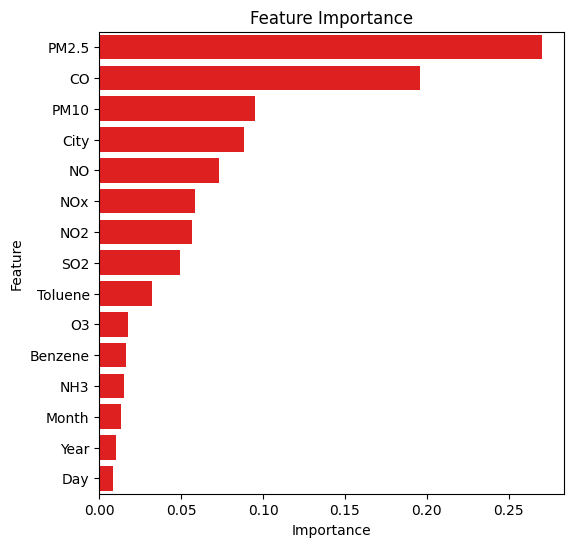

In [61]:
plt.figure(figsize=(6,6))
sns.barplot(
    data= feature_importance,
    x="Importance", y="Feature", color="red")
plt.title("Feature Importance")
plt.show

## 7. Model Evaluation and Visualization

#### 7.1 Actual vs Predicted Values Table

In [62]:
comparison=pd.DataFrame({
    "Actual AQI": y_test,
    "Predicted AQI": y_pred_best})
comparison.head()

,Actual AQI,Predicted AQI
8450,141.0,108.680
23640,209.0,204.805
4129,111.0,99.550
20369,124.0,153.760
6121,81.0,83.230


#### 7.2 Actual vs Predicted Value Scatter Plot

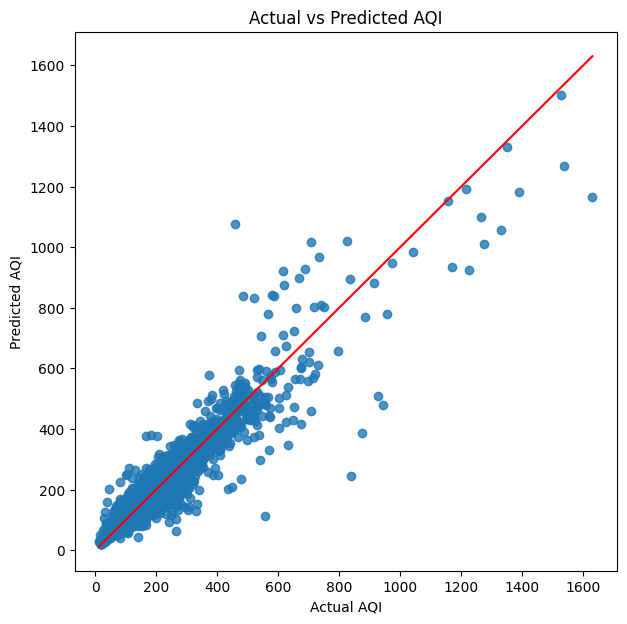

In [63]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.8
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

## 7.3 Residual Analysis and Plotting

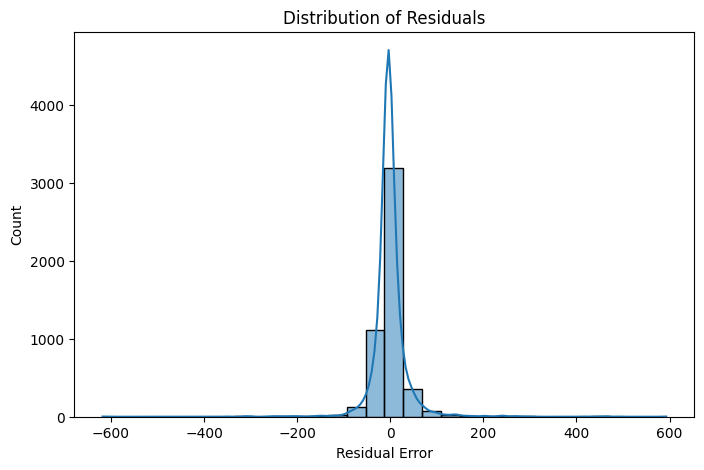

In [64]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Distribution of Residuals")

plt.xlabel("Residual Error")

plt.show()

## 7.4 Saving the Model

In [65]:
import joblib

In [66]:
joblib.dump(best_rf, "AQI_Prediction_Model.pkl")

['AQI_Prediction_Model.pkl']

In [67]:
model = joblib.load("AQI_Prediction_Model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


## 8. Predicting Using the Saved Model

### 8.1 Loading the Saved Model

In [68]:
import joblib
model= joblib.load("AQI_Prediction_Model.pkl")
print("MODEL LOADED SUCCESSFULLY !!!!")

MODEL LOADED SUCCESSFULLY !!!!


### 8.2 Predicting Using the Model

In [69]:
predictions = model.predict(X_test)

print("First 10 Predictions:")
print(predictions[:10])

First 10 Predictions:
[108.68  204.805  99.55  153.76   83.23   66.065  63.765 100.885 133.44
  64.345]


### 8.3 Comparison of Actual and Predicted

In [70]:
comparison = pd.DataFrame({
    "Actual AQI": y_test.values,
    "Predicted AQI": predictions
})

comparison.head(10)

,Actual AQI,Predicted AQI
0,141.0,108.680
1,209.0,204.805
2,111.0,99.550
3,124.0,153.760
4,81.0,83.230
5,54.0,66.065
6,74.0,63.765
7,99.0,100.885
8,97.0,133.440
9,60.0,64.345


### 8.4 Evaluate the Loaded Model

In [71]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score :", r2_score(y_test, predictions))
print("MAE      :", mean_absolute_error(y_test, predictions))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, predictions)))

R² Score : 0.9126832638598259
MAE      : 20.472274312541916
RMSE     : 39.98572999482486


# 9. POWERBI INTEGRATION

## 9.1 Air Quality Index Dashboard

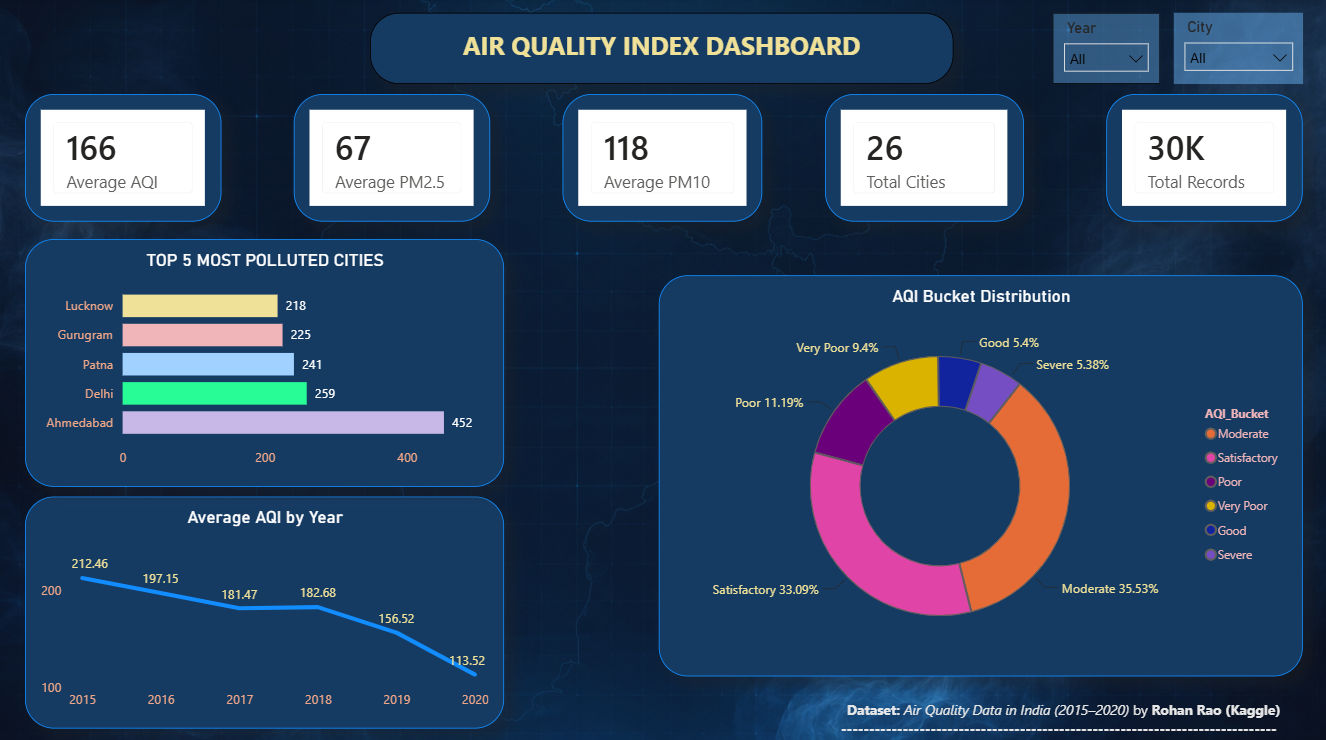

In [72]:
from IPython.display import Image, display

display(Image("Dashboard_page1.png"))

##### ✓ Displays key performance indicators (Average AQI, PM2.5, PM10, Total Cities, Total Records).
##### ✓ Shows Top 5 Most Polluted Cities.
##### ✓ Displays AQI Bucket Distribution.
##### ✓ Shows Year-wise AQI Trend.

## 9.2 Pollutant Trend and Analysis

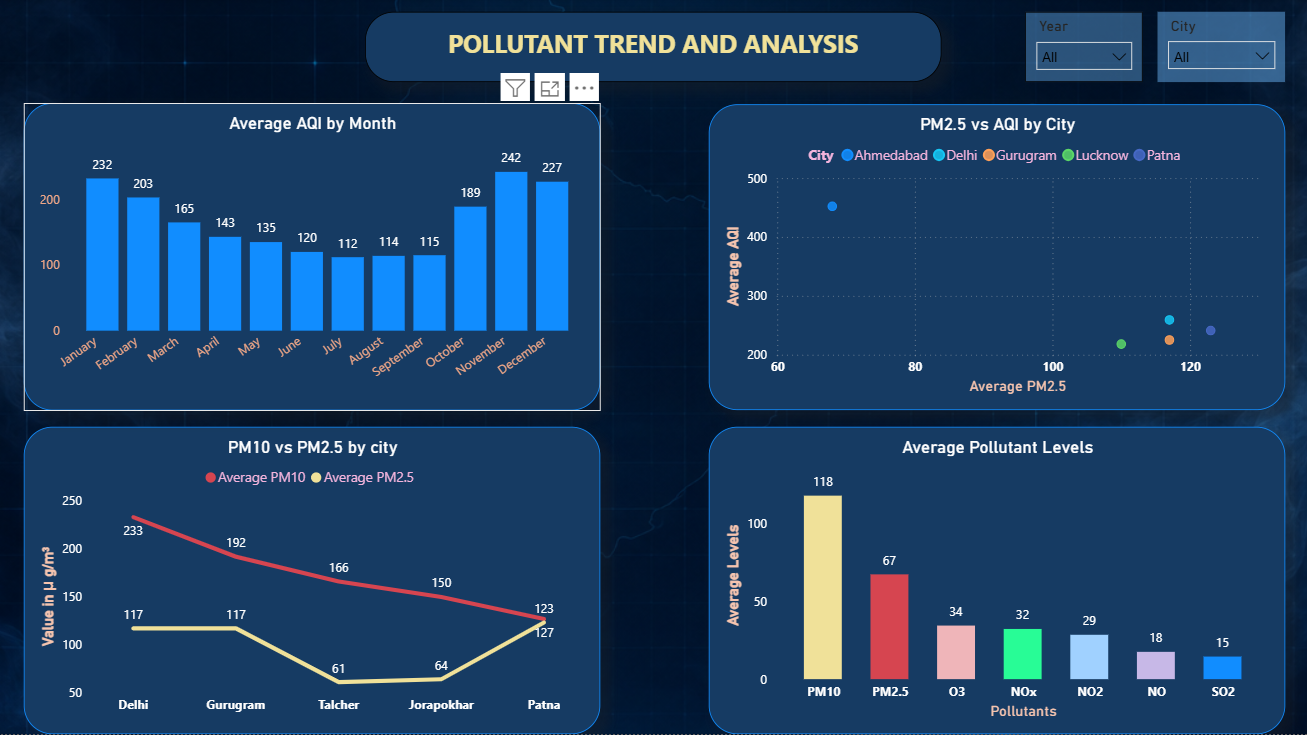

In [73]:
display(Image("Dashboard_page2.png"))

##### ✓ Monthly AQI analysis.
##### ✓ PM2.5 vs AQI relationship.
##### ✓ PM10 vs PM2.5 comparison.
##### ✓ Average pollutant concentration analysis.

### 9.3 Insights and Conclusion

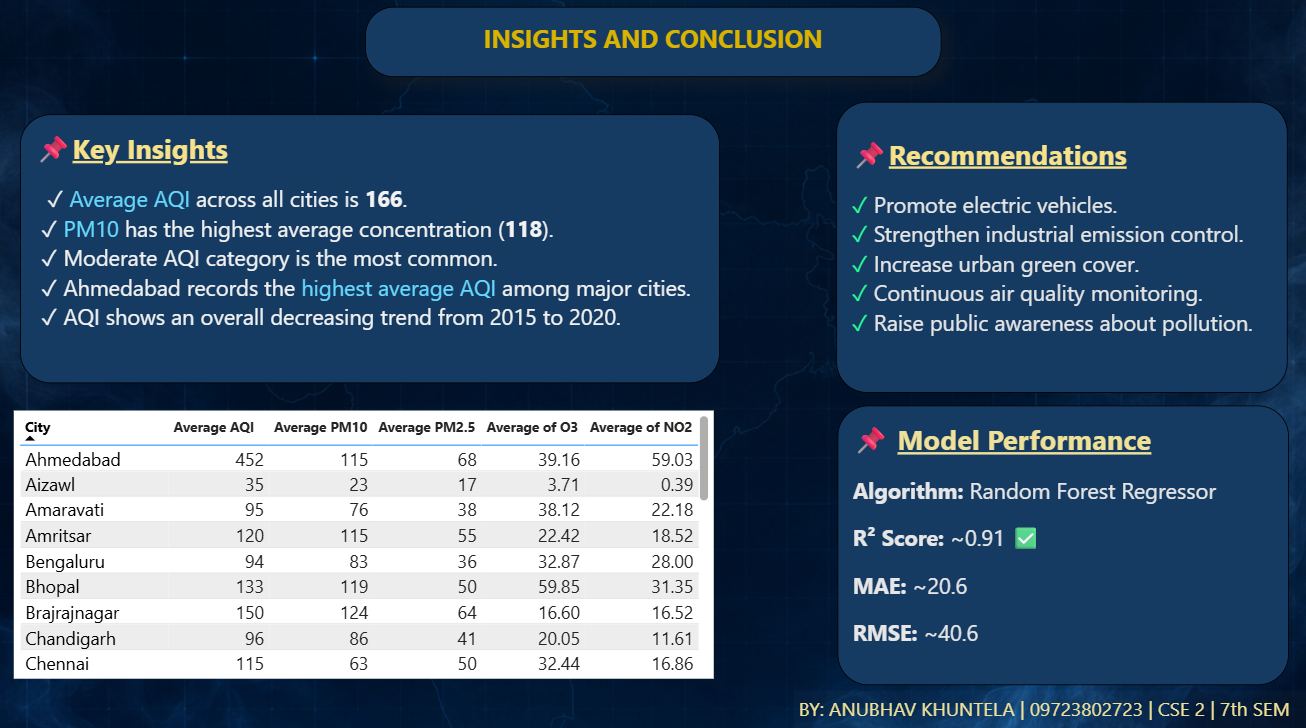

In [74]:
display(Image("Dashboard_page3.png"))

##### ✓ Key findings from the dataset.
##### ✓ Recommendations for improving air quality.
##### ✓ Machine Learning model performance.
##### ✓ City-wise pollutant summary table.

##### The integration of Machine Learning and Power BI provides both predictive analytics and interactive visualization. While the Machine Learning model predicts the Air Quality Index (AQI), the Power BI dashboard enables users to explore historical trends, pollutant distribution, and city-wise air quality through interactive visualizations. Together, they form a comprehensive Air Quality Analysis and Prediction System.

# 10. Conclusion

The primary objective of this project was to develop a Machine Learning model capable of predicting the Air Quality Index (AQI) using various air pollutant parameters collected from different cities across India.

The following conclusions can be drawn from this project:

1. The air quality dataset was successfully preprocessed by handling missing values, removing irrelevant features, encoding categorical variables, and extracting useful temporal features such as Year, Month, and Day. These preprocessing steps improved the quality of the dataset and prepared it for machine learning.

2. Exploratory Data Analysis (EDA) provided valuable insights into pollutant distribution, AQI trends, city-wise pollution levels, and the relationship between different pollutants. It also helped identify the major factors affecting air quality.

3. Multiple Machine Learning regression algorithms, including Decision Tree Regressor, Random Forest Regressor, Extra Trees Regressor, and Gradient Boosting Regressor, were trained and evaluated to compare their prediction performance.

4. Hyperparameter tuning was performed to optimize the Random Forest model, resulting in improved prediction accuracy and better generalization on unseen data.

5. Among all the trained models, the Random Forest Regressor achieved the best overall performance with an R² score of approximately **0.91**, along with lower MAE and RMSE values, making it the most suitable model for AQI prediction.

6. Feature importance analysis revealed that pollutants such as **PM2.5, PM10, NO₂, CO, and SO₂** contributed significantly to AQI prediction, highlighting their major impact on air quality.

7. The trained model was successfully saved using the Joblib library, allowing it to be reused for future predictions without retraining the model.

8. Overall, the project demonstrates that Machine Learning techniques can effectively predict Air Quality Index (AQI) with high accuracy and can support environmental monitoring, pollution control strategies, and informed decision-making for improving public health.

9. An interactive Power BI dashboard was also developed to visualize AQI trends, pollutant distribution, city-wise analysis, and model insights, making the overall system more informative and user-friendly.

# 11. Project Summary 

## 11.1 Future Scope

- Integrate real-time air quality sensor data for live AQI prediction.
- Develop a web application for public access to AQI forecasts.
- Improve prediction accuracy using advanced models such as XGBoost and LightGBM.
- Include meteorological parameters such as temperature, humidity, rainfall, and wind speed.
- Deploy the model on cloud platforms for real-time monitoring.
- Integrate the trained Machine Learning model with the Power BI dashboard to provide interactive visualization and prediction.

## 11.2 Tools & Technologies Used

- Python
- Jupyter Notebook
- Power BI
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

## 11.3 Libraries Used

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- joblib

## 11.4 Dataset Used

Dataset Name: Air Quality Data in India (2015–2020)

Source: Kaggle

File Used: city_day.csv

Author: Rohan Rao

## 11.5 References

1. Rohan Rao. Air Quality Data in India (2015–2020), Kaggle.
2. Central Pollution Control Board (CPCB), Government of India.
3. Scikit-learn Documentation.
4. Pandas Documentation.
5. Matplotlib Documentation.
6. Seaborn Documentation.
7. Power BI Documentation.